In [ ]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

PARQUET_DIR = os.path.expanduser('~/kkbox-churn/data/parquet/')

con = duckdb.connect()
con.execute("SET threads=2")
con.execute("SET memory_limit='10GB'")
con.execute("SET max_temp_directory_size='100GB'")
con.execute("SET preserve_insertion_order=false")

con.execute(f"""
    CREATE OR REPLACE VIEW logs AS
    SELECT * FROM '{PARQUET_DIR}logs_all_clean.parquet'
""")

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 100

print("Ready.")

Ready.


In [20]:
print("=== SCHEMA ===")
sample = con.execute("SELECT * FROM logs LIMIT 3").df()
print(sample.dtypes)
print(sample)

print("\n=== BASIC STATS ===")
stats = con.execute("""
    SELECT
        COUNT(*)                    AS total_rows,
        COUNT(DISTINCT msno)        AS unique_users,
        MIN(date)                   AS min_date,
        MAX(date)                   AS max_date,
        ROUND(AVG(num_25), 2)       AS avg_num_25,
        ROUND(AVG(num_50), 2)       AS avg_num_50,
        ROUND(AVG(num_75), 2)       AS avg_num_75,
        ROUND(AVG(num_985), 2)      AS avg_num_985,
        ROUND(AVG(num_100), 2)      AS avg_num_100,
        ROUND(AVG(num_unq), 2)      AS avg_num_unq,
        ROUND(AVG(CASE WHEN total_secs <= 86400
            THEN total_secs ELSE NULL END), 2) AS avg_secs_clean,
        SUM(CASE WHEN total_secs > 86400
            THEN 1 ELSE 0 END)      AS overflow_rows
    FROM logs
""").df()
print(stats.T)

=== SCHEMA ===
msno              str
date            int64
num_25          int64
num_50          int64
num_75          int64
num_985         int64
num_100         int64
num_unq         int64
total_secs    float64
dtype: object
                                           msno      date  num_25  num_50  \
0  x58WueIUqmhUwZVt+bkZKZ41uNJgB/wH6vE1OWW1+6o=  20150217       0       0   
1  x58WueIUqmhUwZVt+bkZKZ41uNJgB/wH6vE1OWW1+6o=  20150509       1       0   
2  x58WueIUqmhUwZVt+bkZKZ41uNJgB/wH6vE1OWW1+6o=  20150714       0       2   

   num_75  num_985  num_100  num_unq  total_secs  
0       0        0       57       57   13081.559  
1       0        0       14       15    3197.920  
2       0        1       91       57   22214.389  

=== BASIC STATS ===
                           0
total_rows      2.504703e+08
unique_users    8.551600e+05
min_date        2.015010e+07
max_date        2.017033e+07
avg_num_25      6.510000e+00
avg_num_50      1.610000e+00
avg_num_75      1.010000e+00
avg_num

     month  active_users  avg_songs_per_day  avg_completion_rate  avg_skip_rate  avg_secs
0   201501        345193              43.11               0.7165         0.1601   8722.48
1   201502        350006              42.45               0.7112         0.1641   8520.87
2   201503        357264              42.73               0.7153         0.1620   8584.92
3   201504        363686              41.75               0.7147         0.1617   8399.91
4   201505        369156              37.82               0.7261         0.1482   7787.68
5   201506        373146              42.22               0.7141         0.1652   8347.41
6   201507        384248              44.02               0.7037         0.1762   8555.47
7   201508        403868              42.76               0.7013         0.1771   8336.74
8   201509        419051              42.10               0.7043         0.1757   8233.79
9   201510        441077              41.63               0.7084         0.1718   8185.27
10  201511

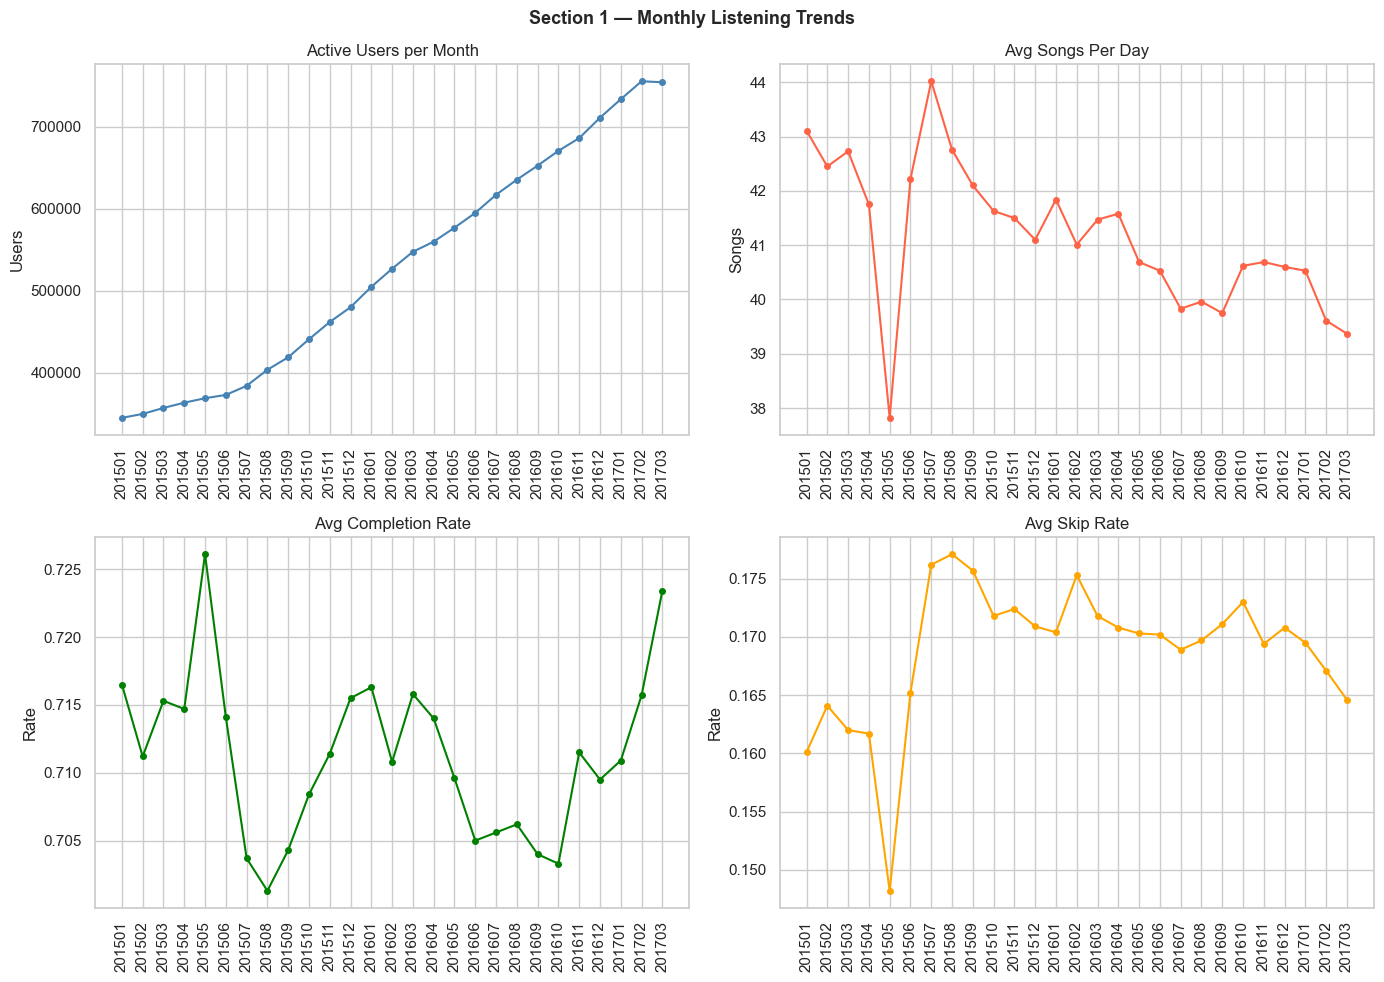

In [21]:
monthly = con.execute("""
    SELECT
        SUBSTR(CAST(date AS VARCHAR), 1, 6)     AS month,
        COUNT(DISTINCT msno)                     AS active_users,
        ROUND(AVG(num_25+num_50+num_75+
            num_985+num_100), 2)                 AS avg_songs_per_day,
        ROUND(AVG(num_100*1.0/NULLIF(
            num_25+num_50+num_75+num_985+num_100,0)), 4)
                                                 AS avg_completion_rate,
        ROUND(AVG(num_25*1.0/NULLIF(
            num_25+num_50+num_75+num_985+num_100,0)), 4)
                                                 AS avg_skip_rate,
        ROUND(AVG(CASE WHEN total_secs <= 86400
            THEN total_secs ELSE NULL END), 2)   AS avg_secs
    FROM logs
    GROUP BY month
    ORDER BY month ASC
""").df()

print(monthly.to_string())

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0,0].plot(monthly['month'], monthly['active_users'],
               marker='o', color='steelblue', markersize=4)
axes[0,0].set_title('Active Users per Month')
axes[0,0].set_ylabel('Users')
axes[0,0].tick_params(axis='x', rotation=90)

axes[0,1].plot(monthly['month'], monthly['avg_songs_per_day'],
               marker='o', color='tomato', markersize=4)
axes[0,1].set_title('Avg Songs Per Day')
axes[0,1].set_ylabel('Songs')
axes[0,1].tick_params(axis='x', rotation=90)

axes[1,0].plot(monthly['month'], monthly['avg_completion_rate'],
               marker='o', color='green', markersize=4)
axes[1,0].set_title('Avg Completion Rate')
axes[1,0].set_ylabel('Rate')
axes[1,0].tick_params(axis='x', rotation=90)

axes[1,1].plot(monthly['month'], monthly['avg_skip_rate'],
               marker='o', color='orange', markersize=4)
axes[1,1].set_title('Avg Skip Rate')
axes[1,1].set_ylabel('Rate')
axes[1,1].tick_params(axis='x', rotation=90)

plt.suptitle('Section 1 — Monthly Listening Trends',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Users with history: 855,160
count    855160.000000
mean        292.892862
std         232.460358
min           1.000000
25%          85.000000
50%         243.000000
75%         470.000000
max         821.000000
Name: total_active_days, dtype: float64
    bucket  total_users  churn_rate
0        0       115800    0.055268
1     1-30       103665    0.094304
2    31-90       118741    0.099258
3   91-180       129579    0.093248
4  181-365       200193    0.095253
5     365+       302982    0.093128


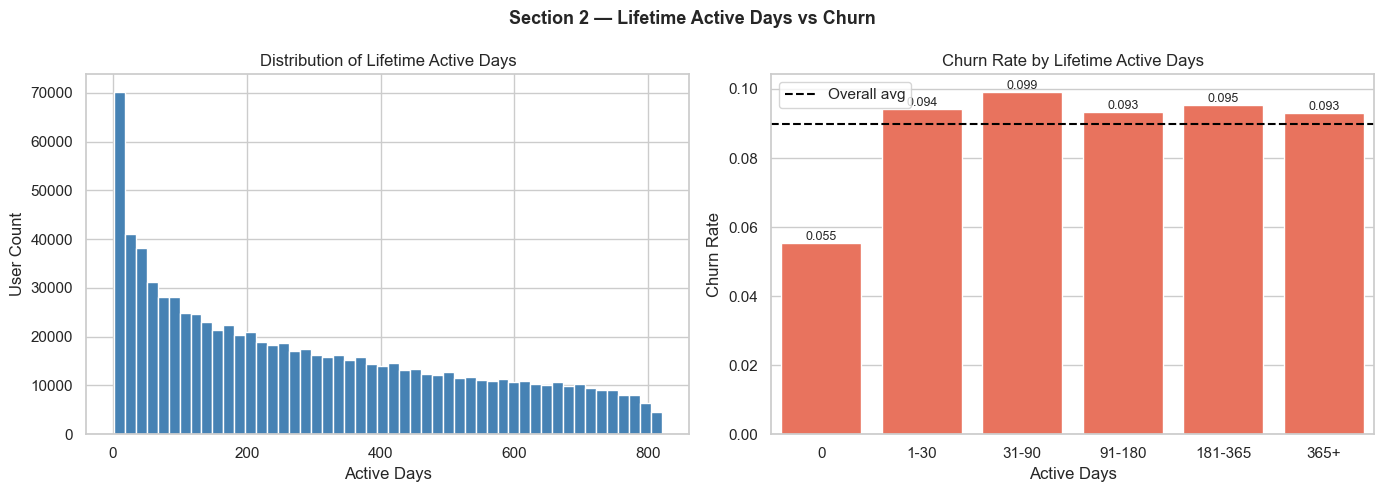

In [23]:
active_dist = con.execute("""
    SELECT
        msno,
        COUNT(DISTINCT date) AS total_active_days
    FROM logs
    GROUP BY msno
""").df()

print(f"Users with history: {len(active_dist):,}")
print(active_dist['total_active_days'].describe())

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(active_dist['total_active_days'], bins=50,
             color='steelblue', edgecolor='white')
axes[0].set_title('Distribution of Lifetime Active Days')
axes[0].set_xlabel('Active Days')
axes[0].set_ylabel('User Count')

# Churn rate by active days bucket
labels_df = con.execute(f"""
    SELECT * FROM '{PARQUET_DIR}train_v2.parquet'
""").df()

active_labeled = active_dist.merge(labels_df, on='msno', how='right')
active_labeled['total_active_days'] = active_labeled[
    'total_active_days'].fillna(0)

active_labeled['bucket'] = pd.cut(
    active_labeled['total_active_days'],
    bins=[-1, 0, 30, 90, 180, 365, 9999],
    labels=['0', '1-30', '31-90', '91-180', '181-365', '365+']
)

summary = active_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Lifetime Active Days')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Section 2 — Lifetime Active Days vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Users with 30d activity: 754,551
Users with zero 30d activity: 216,409
  bucket  total_users  churn_rate
0      0       216409    0.090985
1    1-3        73351    0.130264
2    4-7        79868    0.117669
3   8-15       152888    0.096175
4  16-31       448444    0.075780


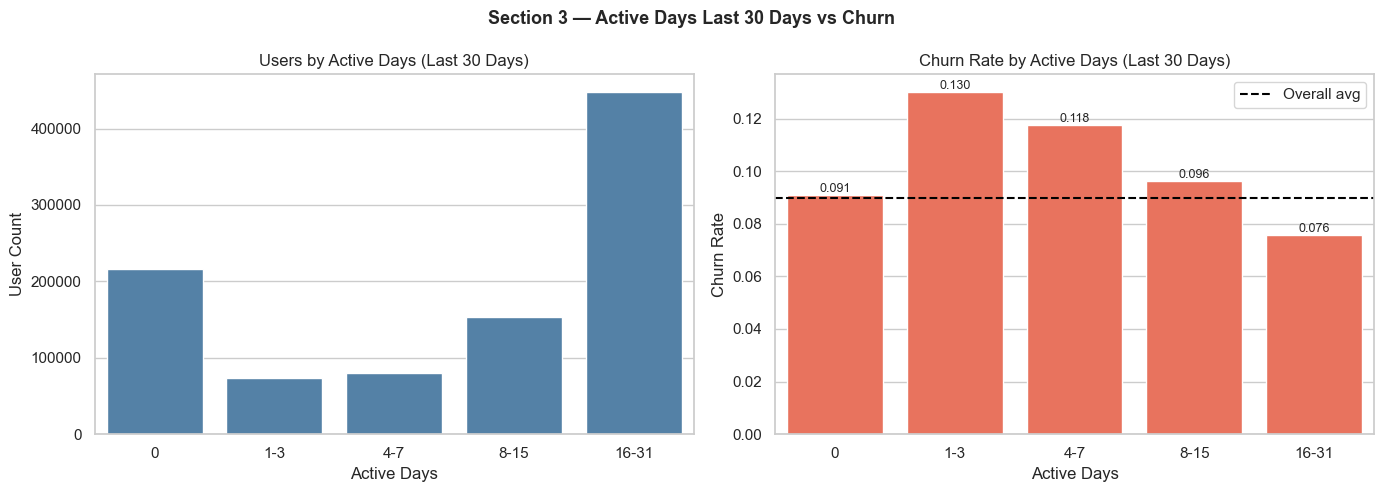

In [24]:
recent_30d = con.execute("""
    SELECT
        msno,
        COUNT(DISTINCT date) AS active_days_30d
    FROM logs
    WHERE date >= 20170301
    GROUP BY msno
""").df()

recent_labeled = recent_30d.merge(labels_df, on='msno', how='right')
recent_labeled['active_days_30d'] = recent_labeled[
    'active_days_30d'].fillna(0)

print(f"Users with 30d activity: {(recent_labeled['active_days_30d']>0).sum():,}")
print(f"Users with zero 30d activity: {(recent_labeled['active_days_30d']==0).sum():,}")

recent_labeled['bucket'] = pd.cut(
    recent_labeled['active_days_30d'],
    bins=[-1, 0, 3, 7, 15, 31],
    labels=['0', '1-3', '4-7', '8-15', '16-31']
)

summary = recent_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Active Days (Last 30 Days)')
axes[0].set_xlabel('Active Days')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Active Days (Last 30 Days)')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Section 3 — Active Days Last 30 Days vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Users with 15d activity: 715,415
Users with zero 15d activity: 255,545
  bucket  total_users  churn_rate
0      0       255545    0.130470
1    1-3       114061    0.097220
2    4-7       135409    0.074700
3   8-10       106915    0.070636
4  11-15       256069    0.068946


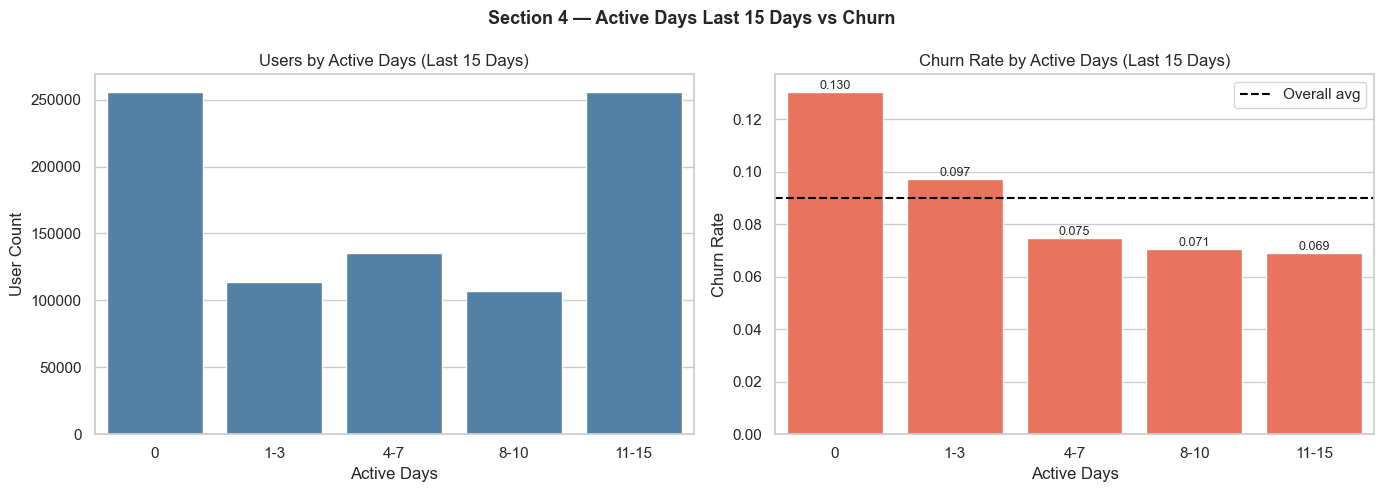

In [25]:
recent_15d = con.execute("""
    SELECT
        msno,
        COUNT(DISTINCT date) AS active_days_15d
    FROM logs
    WHERE date >= 20170316
    GROUP BY msno
""").df()

recent_15d_labeled = recent_15d.merge(labels_df, on='msno', how='right')
recent_15d_labeled['active_days_15d'] = recent_15d_labeled[
    'active_days_15d'].fillna(0)

print(f"Users with 15d activity: {(recent_15d_labeled['active_days_15d']>0).sum():,}")
print(f"Users with zero 15d activity: {(recent_15d_labeled['active_days_15d']==0).sum():,}")

recent_15d_labeled['bucket'] = pd.cut(
    recent_15d_labeled['active_days_15d'],
    bins=[-1, 0, 3, 7, 10, 15],
    labels=['0', '1-3', '4-7', '8-10', '11-15']
)

summary = recent_15d_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Active Days (Last 15 Days)')
axes[0].set_xlabel('Active Days')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Active Days (Last 15 Days)')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9)

plt.suptitle('Section 4 — Active Days Last 15 Days vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

count    970960.000000
mean        143.300984
std         326.232726
min           1.000000
25%           1.000000
50%           2.000000
75%          20.000000
max         999.000000
Name: days_since_last_listen, dtype: float64
     bucket  total_users  churn_rate
0  same day       416825    0.063842
1      1-7d       240125    0.069585
2     8-15d        54848    0.176397
3    16-30d        41250    0.342230
4    31-60d        28863    0.231715
5      60+d        73249    0.097339
6     never       115800    0.055268


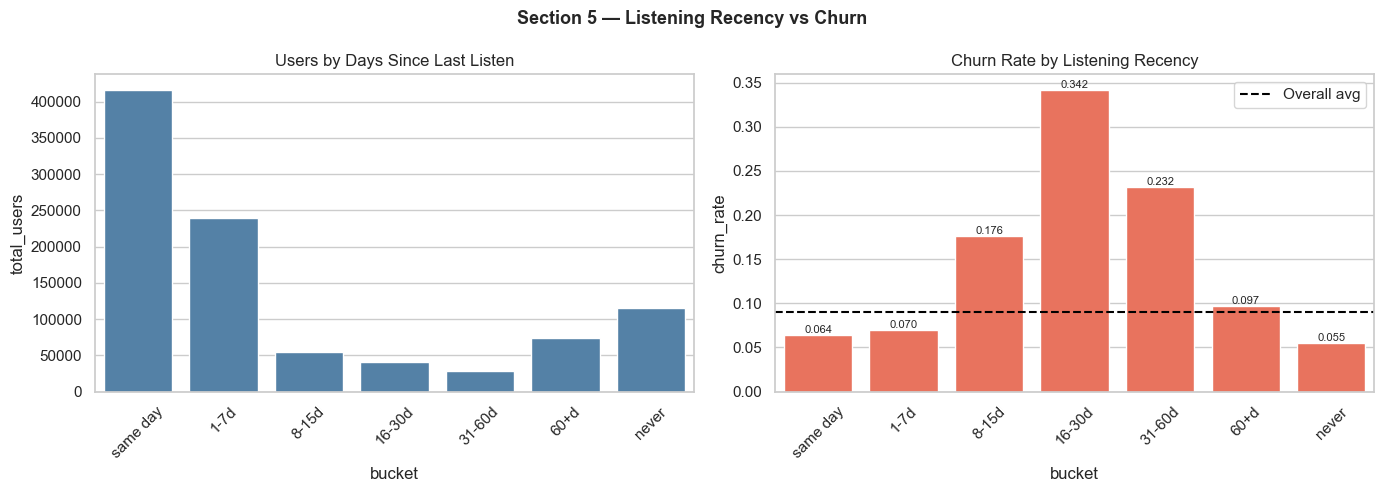

In [26]:
recency = con.execute("""
    SELECT
        msno,
        MAX(date) AS last_listen_date
    FROM logs
    GROUP BY msno
""").df()

recency_labeled = recency.merge(labels_df, on='msno', how='right')

# Calculate days since last listen relative to April 1 2017
recency_labeled['days_since_last_listen'] = recency_labeled[
    'last_listen_date'].apply(
    lambda x: (pd.Timestamp('20170401') -
               pd.Timestamp(str(int(x)))).days
    if pd.notna(x) else 999
)

print(recency_labeled['days_since_last_listen'].describe())

recency_labeled['bucket'] = pd.cut(
    recency_labeled['days_since_last_listen'],
    bins=[-1, 1, 7, 15, 30, 60, 998, 999],
    labels=['same day', '1-7d', '8-15d',
            '16-30d', '31-60d', '60+d', 'never']
)

summary = recency_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Days Since Last Listen')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Listening Recency')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 5 — Listening Recency vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

       bucket  total_users  churn_rate
0  no history       115800    0.055268
1       0-20%        25774    0.059595
2      20-40%        49258    0.092290
3      40-60%       161976    0.099008
4      60-80%       358099    0.097096
5     80-100%       260053    0.092447


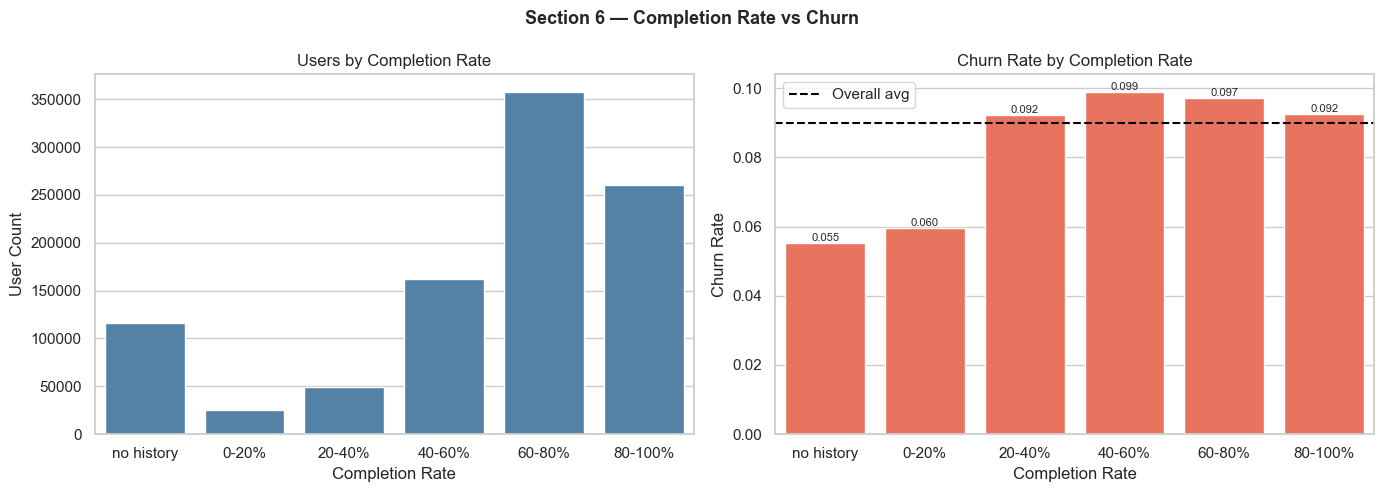

In [27]:
completion = con.execute("""
    SELECT
        msno,
        SUM(num_100) AS total_completed,
        SUM(num_25+num_50+num_75+num_985+num_100) AS total_songs,
        ROUND(SUM(num_100)*1.0 / NULLIF(
            SUM(num_25+num_50+num_75+num_985+num_100),0), 4)
            AS completion_rate
    FROM logs
    GROUP BY msno
""").df()

completion_labeled = completion.merge(labels_df, on='msno', how='right')
completion_labeled['total_songs'] = completion_labeled[
    'total_songs'].fillna(0)
completion_labeled['completion_rate'] = completion_labeled[
    'completion_rate'].fillna(-1)  # -1 = no listening history

# Include no-history as separate bucket
completion_labeled['bucket'] = pd.cut(
    completion_labeled['completion_rate'],
    bins=[-2, -0.5, 0.2, 0.4, 0.6, 0.8, 1.001],
    labels=['no history', '0-20%', '20-40%',
            '40-60%', '60-80%', '80-100%']
)

summary = completion_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Completion Rate')
axes[0].set_xlabel('Completion Rate')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Completion Rate')
axes[1].set_xlabel('Completion Rate')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 6 — Completion Rate vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

       bucket  total_users  churn_rate
0  no history       115800    0.055268
1       0-10%       210269    0.092724
2      10-20%       296060    0.096626
3      20-30%       185007    0.097748
4      30-40%        87594    0.097290
5        40%+        76230    0.081595


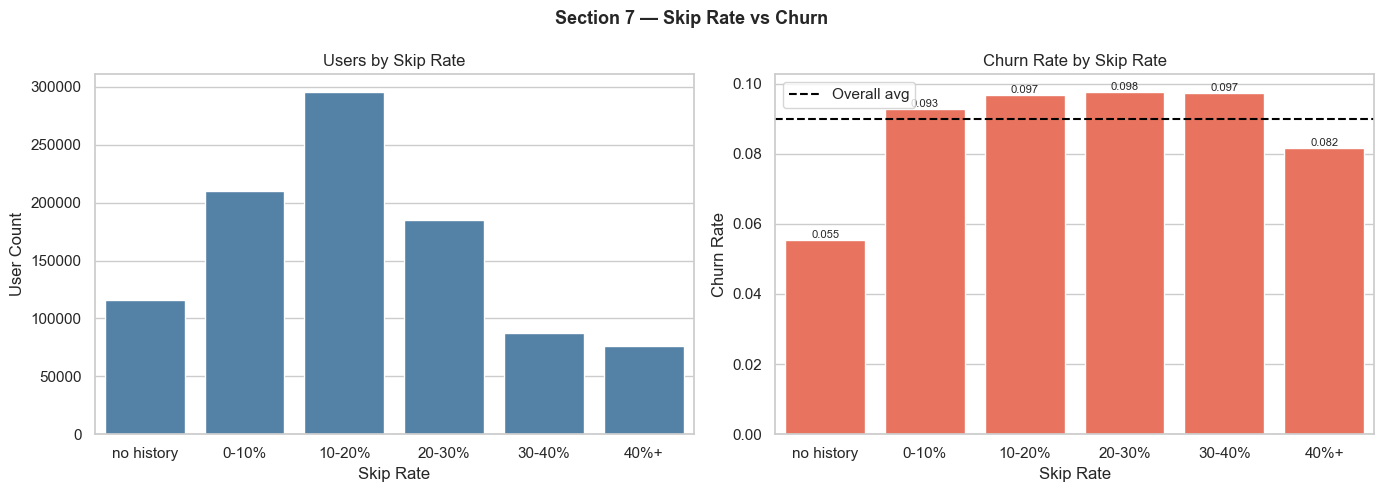

In [28]:
skip = con.execute("""
    SELECT
        msno,
        ROUND(SUM(num_25)*1.0 / NULLIF(
            SUM(num_25+num_50+num_75+num_985+num_100),0), 4)
            AS skip_rate
    FROM logs
    GROUP BY msno
""").df()

skip_labeled = skip.merge(labels_df, on='msno', how='right')
skip_labeled['skip_rate'] = skip_labeled['skip_rate'].fillna(-1)

skip_labeled['bucket'] = pd.cut(
    skip_labeled['skip_rate'],
    bins=[-2, -0.5, 0.1, 0.2, 0.3, 0.4, 1.001],
    labels=['no history', '0-10%', '10-20%',
            '20-30%', '30-40%', '40%+']
)

summary = skip_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Skip Rate')
axes[0].set_xlabel('Skip Rate')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Skip Rate')
axes[1].set_xlabel('Skip Rate')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 7 — Skip Rate vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

       bucket  total_users  churn_rate
0  no history       115800    0.055268
1        1-10        50185    0.054718
2       11-20       180322    0.079846
3       21-40       392052    0.097607
4       41-80       193656    0.109452
5         80+        38945    0.111003


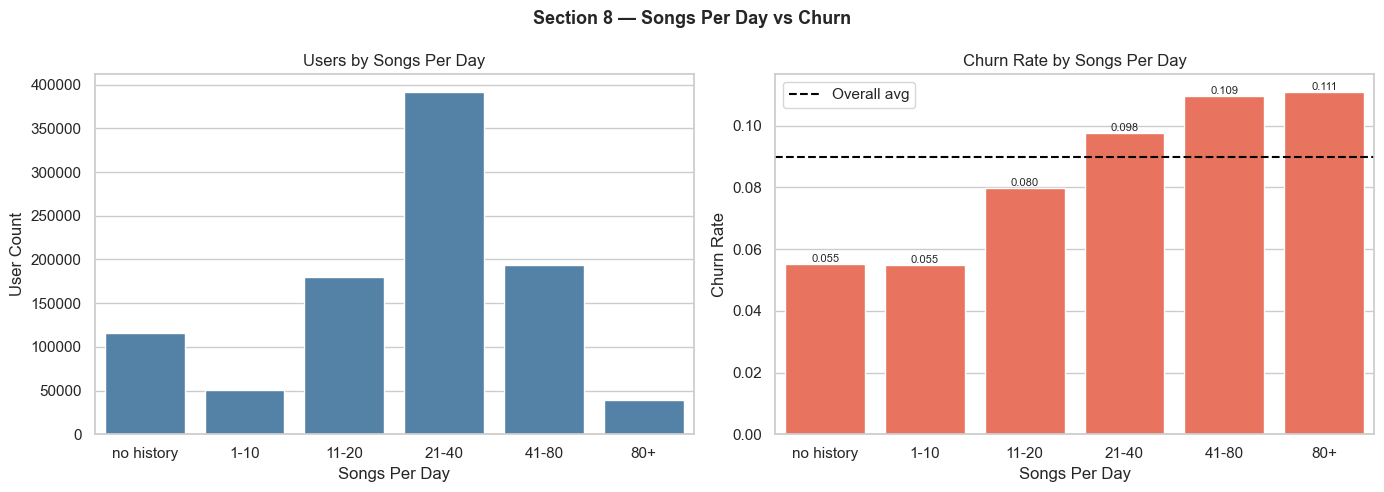

In [29]:
songs_per_day = con.execute("""
    SELECT
        msno,
        COUNT(DISTINCT date) AS active_days,
        SUM(num_25+num_50+num_75+num_985+num_100) AS total_songs,
        ROUND(SUM(num_25+num_50+num_75+num_985+num_100)*1.0 /
            NULLIF(COUNT(DISTINCT date), 0), 2) AS songs_per_day
    FROM logs
    GROUP BY msno
""").df()

spd_labeled = songs_per_day.merge(labels_df, on='msno', how='right')
spd_labeled['songs_per_day'] = spd_labeled['songs_per_day'].fillna(-1)

spd_labeled['bucket'] = pd.cut(
    spd_labeled['songs_per_day'],
    bins=[-2, -0.5, 10, 20, 40, 80, 99999],
    labels=['no history', '1-10', '11-20',
            '21-40', '41-80', '80+']
)

summary = spd_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Songs Per Day')
axes[0].set_xlabel('Songs Per Day')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Songs Per Day')
axes[1].set_xlabel('Songs Per Day')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 8 — Songs Per Day vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [30]:
trend = con.execute("""
    SELECT
        msno,
        SUM(CASE WHEN date >= 20170301
            THEN total_secs ELSE 0 END) AS secs_30d,
        SUM(CASE WHEN date BETWEEN 20170201 AND 20170228
            THEN total_secs ELSE 0 END) AS secs_prev30d,
        COUNT(DISTINCT CASE WHEN date >= 20170301
            THEN date ELSE NULL END) AS active_days_30d,
        COUNT(DISTINCT CASE WHEN date BETWEEN 20170201 AND 20170228
            THEN date ELSE NULL END) AS active_days_prev30d
    FROM logs
    GROUP BY msno
""").df()

trend_labeled = trend.merge(labels_df, on='msno', how='right')

for col in ['secs_30d', 'secs_prev30d',
            'active_days_30d', 'active_days_prev30d']:
    trend_labeled[col] = trend_labeled[col].fillna(0)

# Listening trend ratio
trend_labeled['trend_ratio'] = (
    trend_labeled['secs_30d'] /
    trend_labeled['secs_prev30d'].replace(0, np.nan)
)

# Active days trend
trend_labeled['days_trend'] = (
    trend_labeled['active_days_30d'] /
    trend_labeled['active_days_prev30d'].replace(0, np.nan)
)

print("=== TREND RATIO DISTRIBUTION ===")
print(trend_labeled['trend_ratio'].describe())

print(f"\nUsers with both months data: {trend_labeled['trend_ratio'].notna().sum():,}")
print(f"Users active only in March: {((trend_labeled['secs_30d']>0) & (trend_labeled['secs_prev30d']==0)).sum():,}")
print(f"Users active only in Feb: {((trend_labeled['secs_30d']==0) & (trend_labeled['secs_prev30d']>0)).sum():,}")
print(f"Users active in neither: {((trend_labeled['secs_30d']==0) & (trend_labeled['secs_prev30d']==0)).sum():,}")

=== TREND RATIO DISTRIBUTION ===
count    7.558200e+05
mean     8.239325e+00
std      1.586172e+03
min      0.000000e+00
25%      6.785357e-01
50%      1.087496e+00
75%      1.660962e+00
max      1.265176e+06
Name: trend_ratio, dtype: float64

Users with both months data: 755,820
Users active only in March: 25,439
Users active only in Feb: 26,708
Users active in neither: 189,701


     trend_bucket  total_users  churn_rate
7     stopped Mar        26708    0.227722
1    dropped 50%+       100419    0.174798
4         new Mar        25439    0.093164
0  dropped 20-50%       113149    0.089793
6          stable       189172    0.075746
5     silent both       189701    0.071734
2      grew 100%+       137775    0.071711
3    grew 20-100%       188597    0.070775


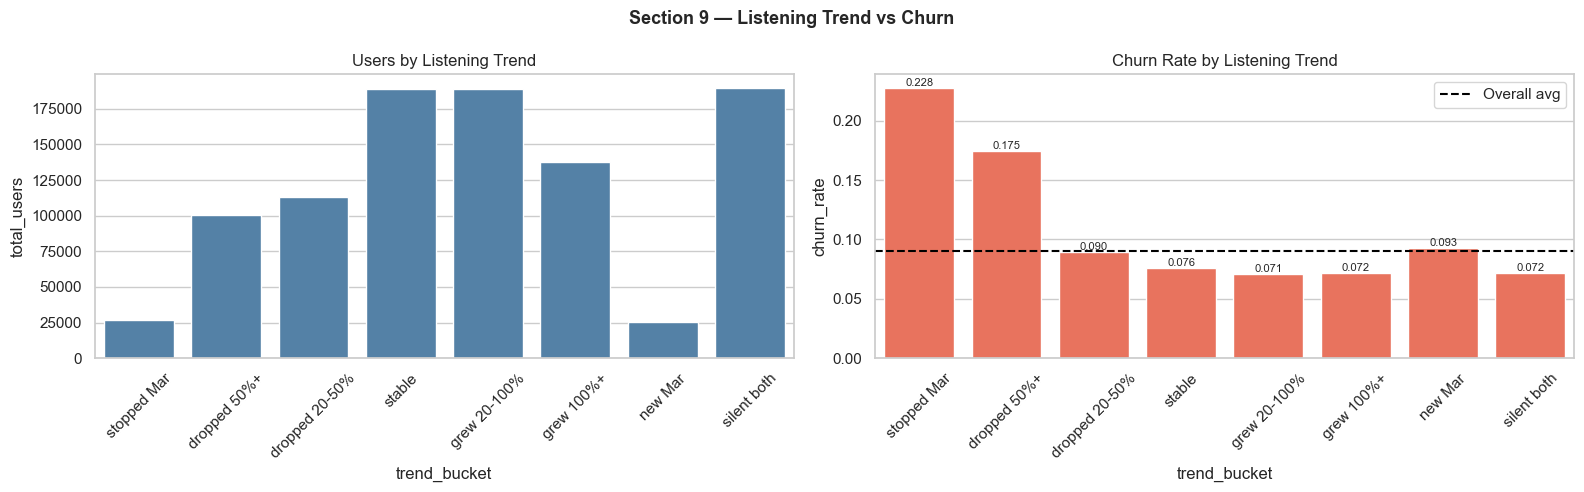

In [31]:
# Cap ratio at 10 for plotting
trend_labeled['trend_ratio_capped'] = trend_labeled[
    'trend_ratio'].clip(0, 10)

# Create 5 groups including special cases
def get_trend_bucket(row):
    if row['secs_30d'] == 0 and row['secs_prev30d'] == 0:
        return 'silent both'
    elif row['secs_30d'] == 0 and row['secs_prev30d'] > 0:
        return 'stopped Mar'
    elif row['secs_30d'] > 0 and row['secs_prev30d'] == 0:
        return 'new Mar'
    elif row['trend_ratio'] < 0.5:
        return 'dropped 50%+'
    elif row['trend_ratio'] < 0.8:
        return 'dropped 20-50%'
    elif row['trend_ratio'] <= 1.2:
        return 'stable'
    elif row['trend_ratio'] <= 2.0:
        return 'grew 20-100%'
    else:
        return 'grew 100%+'

trend_labeled['trend_bucket'] = trend_labeled.apply(
    get_trend_bucket, axis=1
)

summary = trend_labeled.groupby('trend_bucket').agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index().sort_values('churn_rate', ascending=False)

print(summary)

order = ['stopped Mar', 'dropped 50%+', 'dropped 20-50%',
         'stable', 'grew 20-100%', 'grew 100%+',
         'new Mar', 'silent both']

summary['trend_bucket'] = pd.Categorical(
    summary['trend_bucket'], categories=order, ordered=True
)
summary = summary.sort_values('trend_bucket')

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(data=summary, x='trend_bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Listening Trend')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=summary, x='trend_bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Listening Trend')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 9 — Listening Trend vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

       bucket  total_users  churn_rate
0  no history       115800    0.055268
1        1-10        99438    0.065840
2       11-20       288173    0.086844
3       21-40       352413    0.103574
4       41-80       101822    0.111440
5         80+        13314    0.113339


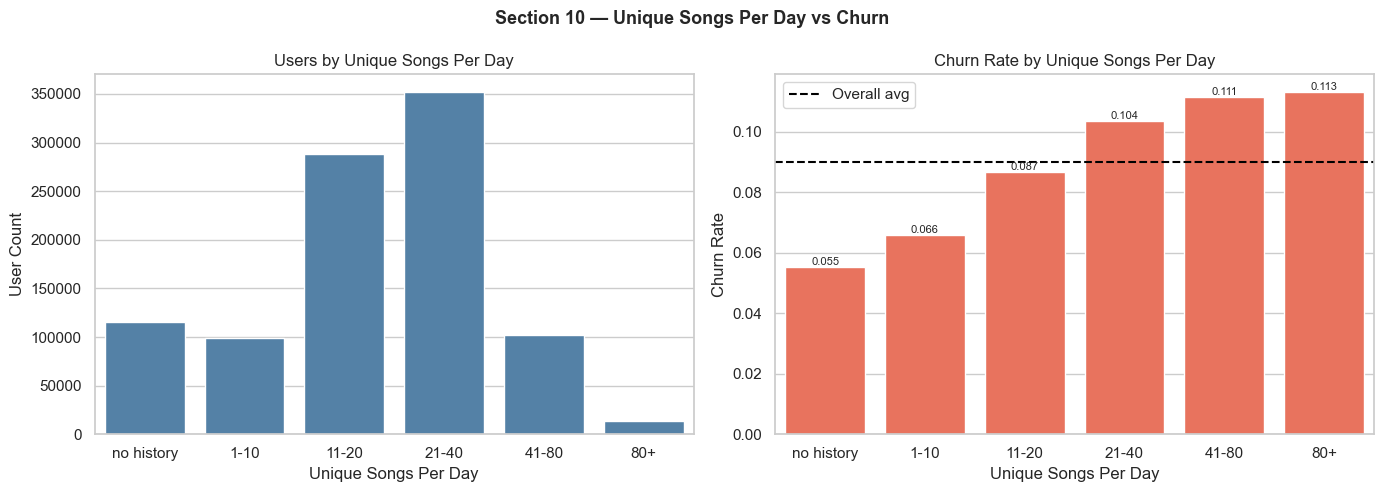

In [32]:
unique_songs = con.execute("""
    SELECT
        msno,
        SUM(num_unq) AS total_unique_songs,
        COUNT(DISTINCT date) AS active_days,
        ROUND(SUM(num_unq)*1.0 /
            NULLIF(COUNT(DISTINCT date), 0), 2) AS unq_per_day
    FROM logs
    GROUP BY msno
""").df()

unq_labeled = unique_songs.merge(labels_df, on='msno', how='right')
unq_labeled['unq_per_day'] = unq_labeled['unq_per_day'].fillna(-1)

unq_labeled['bucket'] = pd.cut(
    unq_labeled['unq_per_day'],
    bins=[-2, -0.5, 10, 20, 40, 80, 99999],
    labels=['no history', '1-10', '11-20',
            '21-40', '41-80', '80+']
)

summary = unq_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Unique Songs Per Day')
axes[0].set_xlabel('Unique Songs Per Day')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Unique Songs Per Day')
axes[1].set_xlabel('Unique Songs Per Day')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 10 — Unique Songs Per Day vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

            bucket  total_users  churn_rate
0       no history       125133    0.055909
1  very consistent        18353    0.088759
2       consistent       555565    0.097225
3         moderate       253707    0.091219
4         variable        15216    0.085174
5    very variable         2986    0.084059


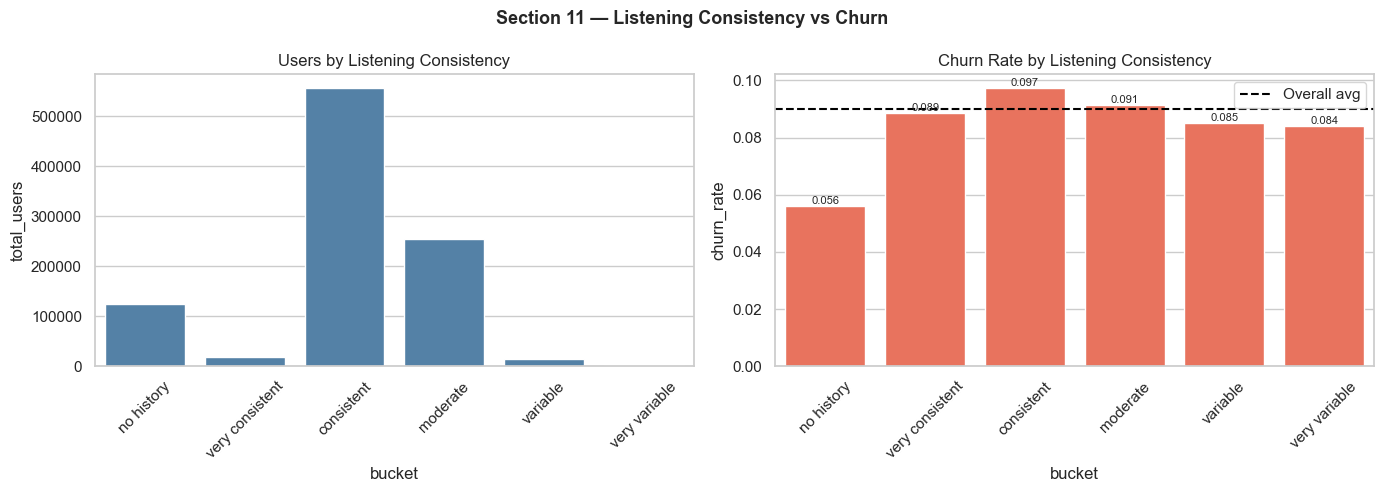

In [33]:
consistency = con.execute("""
    SELECT
        msno,
        STDDEV(num_25+num_50+num_75+num_985+num_100) AS songs_std,
        AVG(num_25+num_50+num_75+num_985+num_100) AS songs_avg,
        COUNT(DISTINCT date) AS active_days
    FROM logs
    GROUP BY msno
""").df()

# Coefficient of variation = std/mean — normalized consistency
consistency['cv'] = consistency['songs_std'] / consistency[
    'songs_avg'].replace(0, np.nan)

consistency_labeled = consistency.merge(labels_df, on='msno', how='right')
consistency_labeled['songs_std'] = consistency_labeled[
    'songs_std'].fillna(-1)
consistency_labeled['cv'] = consistency_labeled['cv'].fillna(-1)

consistency_labeled['bucket'] = pd.cut(
    consistency_labeled['cv'],
    bins=[-2, -0.5, 0.5, 1.0, 1.5, 2.0, 99999],
    labels=['no history', 'very consistent',
            'consistent', 'moderate',
            'variable', 'very variable']
)

summary = consistency_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Listening Consistency')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Listening Consistency')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 11 — Listening Consistency vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Users with final day data: 855,160
       bucket  total_users  churn_rate
0  no history       115800    0.055268
1       0-20%       104899    0.105845
2      20-40%        73826    0.093951
3      40-60%       122372    0.095291
4      60-80%       175168    0.092386
5     80-100%       378895    0.092498


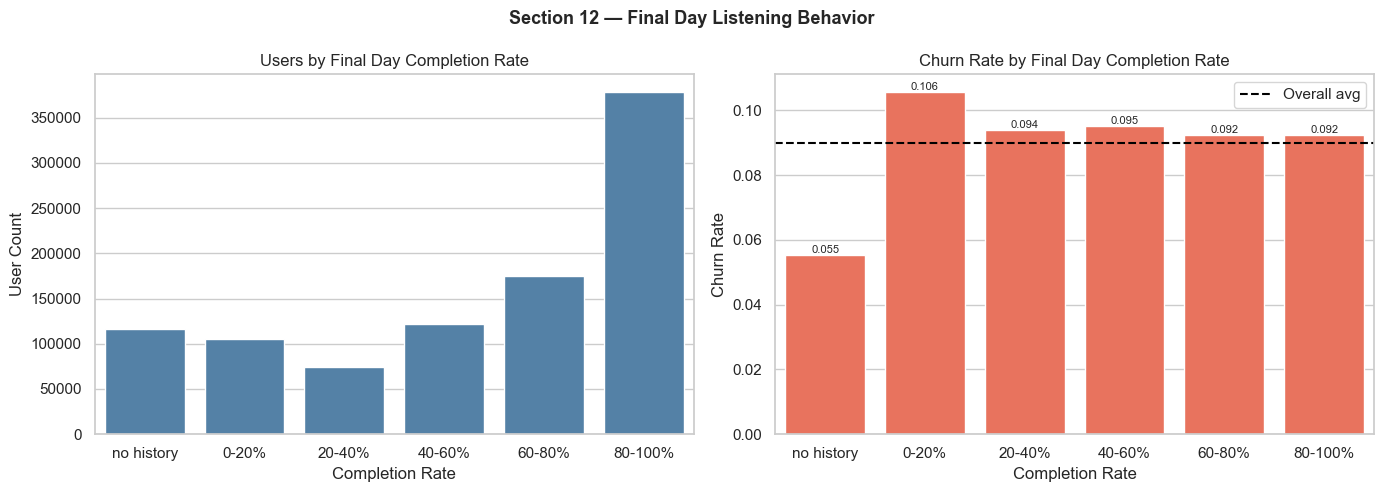

In [34]:
final_day = con.execute("""
    WITH ranked AS (
        SELECT *,
            ROW_NUMBER() OVER (
                PARTITION BY msno
                ORDER BY date DESC
            ) AS rn
        FROM logs
    )
    SELECT
        msno,
        date AS final_day_date,
        num_25+num_50+num_75+num_985+num_100 AS final_day_songs,
        num_100 AS final_day_completed,
        num_25 AS final_day_skipped,
        ROUND(num_100*1.0/NULLIF(
            num_25+num_50+num_75+num_985+num_100,0), 4)
            AS final_day_completion_rate,
        ROUND(num_25*1.0/NULLIF(
            num_25+num_50+num_75+num_985+num_100,0), 4)
            AS final_day_skip_rate,
        total_secs AS final_day_secs
    FROM ranked
    WHERE rn = 1
""").df()

final_labeled = final_day.merge(labels_df, on='msno', how='right')

print(f"Users with final day data: {final_labeled['final_day_date'].notna().sum():,}")

# Final day completion rate
final_labeled['final_day_completion_rate'] = final_labeled[
    'final_day_completion_rate'].fillna(-1)

final_labeled['bucket'] = pd.cut(
    final_labeled['final_day_completion_rate'],
    bins=[-2, -0.5, 0.2, 0.4, 0.6, 0.8, 1.001],
    labels=['no history', '0-20%', '20-40%',
            '40-60%', '60-80%', '80-100%']
)

summary = final_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Final Day Completion Rate')
axes[0].set_xlabel('Completion Rate')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Final Day Completion Rate')
axes[1].set_xlabel('Completion Rate')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 12 — Final Day Listening Behavior',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

    current_auto_renew    recency_bucket  total_users  churn_rate
0                   -1     recent (0-7d)            3    0.666667
1                   -1  moderate (8-30d)            7    1.000000
2                   -1   inactive (30d+)            1    1.000000
3                    0     recent (0-7d)        89701    0.324656
4                    0  moderate (8-30d)        19601    0.774909
5                    0   inactive (30d+)         3891    0.952454
6                    0             never          440    0.993182
7                    1     recent (0-7d)       567246    0.025026
8                    1  moderate (8-30d)        76490    0.112381
9                    1   inactive (30d+)        98220    0.102942
10                   1             never       115360    0.051690


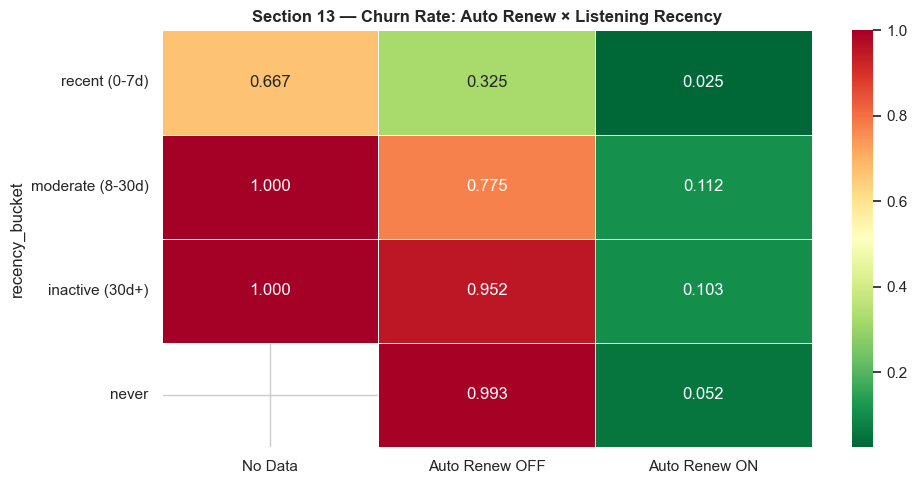

In [35]:
# Load transaction auto-renew status
txn_autorenew = con.execute(f"""
    WITH ranked AS (
        SELECT msno, is_auto_renew,
            ROW_NUMBER() OVER (
                PARTITION BY msno
                ORDER BY transaction_date DESC
            ) AS rn
        FROM (
            SELECT * FROM '{PARQUET_DIR}transactions.parquet'
            UNION ALL
            SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
        )
        WHERE payment_plan_days > 1
    )
    SELECT msno, is_auto_renew AS current_auto_renew
    FROM ranked WHERE rn = 1
""").df()

# Merge recency + auto-renew + labels
cross = recency_labeled[['msno', 'days_since_last_listen']].merge(
    txn_autorenew, on='msno', how='left'
).merge(labels_df, on='msno', how='right')

cross['days_since_last_listen'] = cross[
    'days_since_last_listen'].fillna(999)
cross['current_auto_renew'] = cross[
    'current_auto_renew'].fillna(-1).astype(int)

# Create recency bucket
cross['recency_bucket'] = pd.cut(
    cross['days_since_last_listen'],
    bins=[-1, 7, 30, 998, 999],
    labels=['recent (0-7d)', 'moderate (8-30d)',
            'inactive (30d+)', 'never']
)

summary = cross.groupby(
    ['current_auto_renew', 'recency_bucket'],
    observed=True
).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

pivot = summary.pivot(
    index='recency_bucket',
    columns='current_auto_renew',
    values='churn_rate'
)
pivot.columns = ['No Data', 'Auto Renew OFF', 'Auto Renew ON']

plt.figure(figsize=(10, 5))
sns.heatmap(pivot, annot=True, fmt='.3f',
            cmap='RdYlGn_r', linewidths=0.5,
            annot_kws={'size': 12})
plt.title('Section 13 — Churn Rate: Auto Renew × Listening Recency',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

=== ACTIVE DAYS LAST 60 DAYS ===
  bucket  total_users  churn_rate
0      0       189701    0.071734
1    1-5        69620    0.098377
2   6-15       109951    0.112823
3  16-30       170184    0.116603
4  31-45       186777    0.087816
5  46-60       244727    0.074458


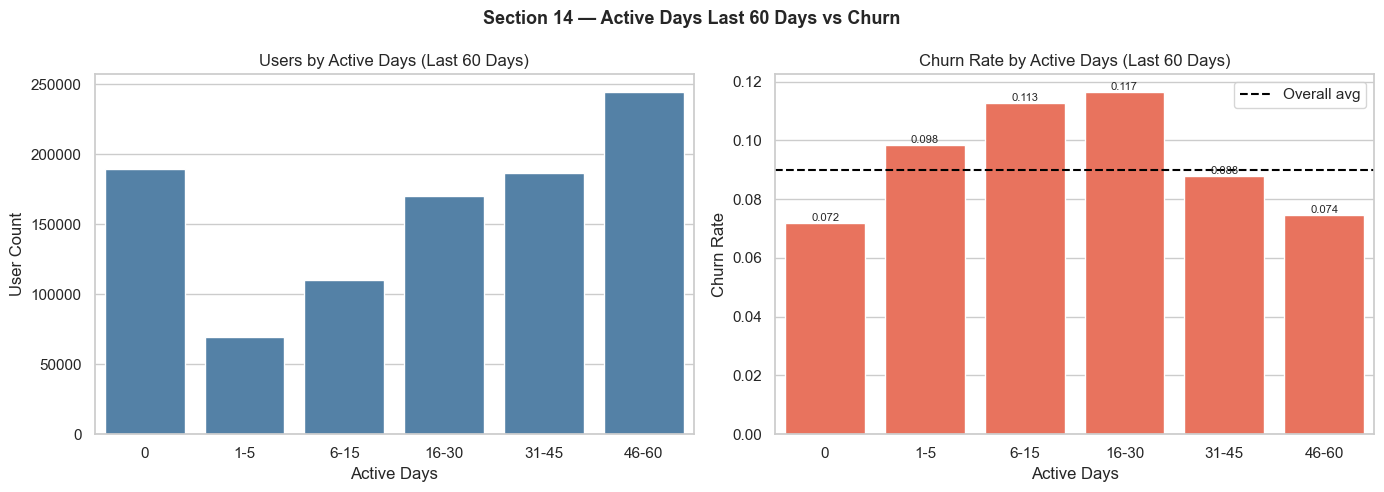

In [36]:
recent_60d = con.execute("""
    SELECT
        msno,
        COUNT(DISTINCT date) AS active_days_60d
    FROM logs
    WHERE date >= 20170201
    GROUP BY msno
""").df()

recent_60d_labeled = recent_60d.merge(labels_df, on='msno', how='right')
recent_60d_labeled['active_days_60d'] = recent_60d_labeled[
    'active_days_60d'].fillna(0)

recent_60d_labeled['bucket'] = pd.cut(
    recent_60d_labeled['active_days_60d'],
    bins=[-1, 0, 5, 15, 30, 45, 60],
    labels=['0', '1-5', '6-15', '16-30', '31-45', '46-60']
)

summary = recent_60d_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print("=== ACTIVE DAYS LAST 60 DAYS ===")
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Active Days (Last 60 Days)')
axes[0].set_xlabel('Active Days')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Active Days (Last 60 Days)')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 14 — Active Days Last 60 Days vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

=== ACTIVE DAYS LAST 120 DAYS ===
   bucket  total_users  churn_rate
0       0       167493    0.067794
1    1-10        75402    0.093738
2   11-30       118074    0.115428
3   31-60       178782    0.100810
4   61-90       186884    0.094588
5  91-120       233904    0.080388


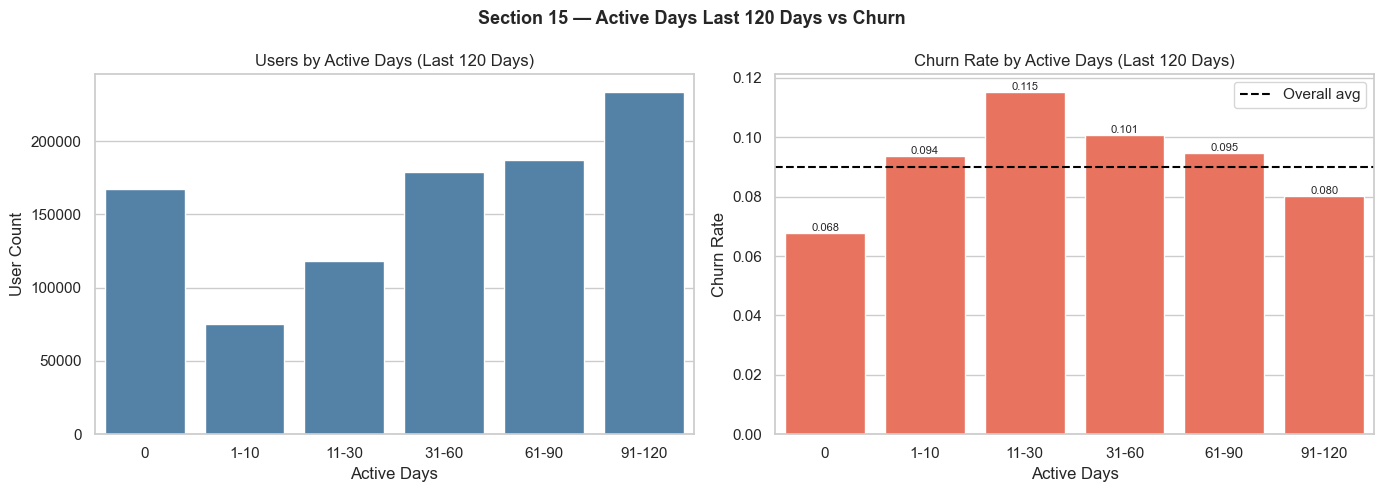

In [37]:
recent_120d = con.execute("""
    SELECT
        msno,
        COUNT(DISTINCT date) AS active_days_120d
    FROM logs
    WHERE date >= 20161201
    GROUP BY msno
""").df()

recent_120d_labeled = recent_120d.merge(labels_df, on='msno', how='right')
recent_120d_labeled['active_days_120d'] = recent_120d_labeled[
    'active_days_120d'].fillna(0)

recent_120d_labeled['bucket'] = pd.cut(
    recent_120d_labeled['active_days_120d'],
    bins=[-1, 0, 10, 30, 60, 90, 120],
    labels=['0', '1-10', '11-30', '31-60', '61-90', '91-120']
)

summary = recent_120d_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print("=== ACTIVE DAYS LAST 120 DAYS ===")
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Active Days (Last 120 Days)')
axes[0].set_xlabel('Active Days')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Active Days (Last 120 Days)')
axes[1].set_xlabel('Active Days')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 15 — Active Days Last 120 Days vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


=== Lifetime ===
      bucket  total_users  churn_rate
0          0       115800    0.055268
1   very low       641182    0.094081
2        low       139808    0.096997
3     medium        43328    0.095112
4       high        15535    0.094046
5  very high        15307    0.095643

=== Last 30 Days ===
      bucket  total_users  churn_rate
0          0       216420    0.090981
1   very low       576001    0.092193
2        low       118189    0.082292
3     medium        32553    0.083740
4       high        13421    0.078459
5  very high        14376    0.071786


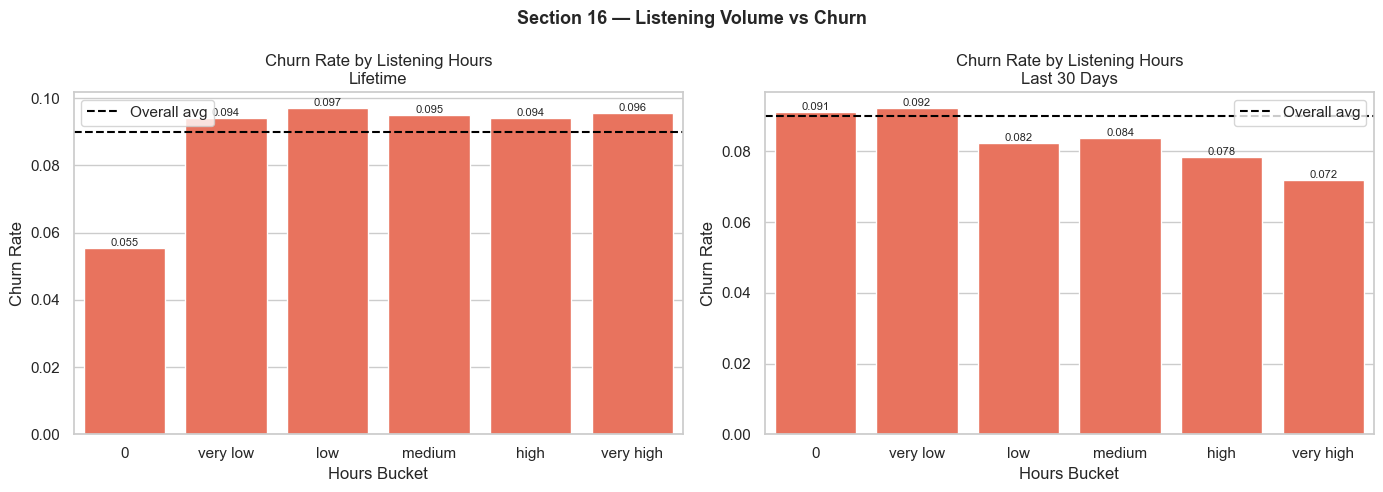

In [38]:
volume = con.execute("""
    SELECT
        msno,
        SUM(CASE WHEN total_secs <= 86400
            THEN total_secs ELSE 86400 END) AS total_secs_clean,
        SUM(CASE WHEN date >= 20170301
            AND total_secs <= 86400
            THEN total_secs ELSE 0 END) AS secs_30d
    FROM logs
    GROUP BY msno
""").df()

volume_labeled = volume.merge(labels_df, on='msno', how='right')
volume_labeled['total_secs_clean'] = volume_labeled[
    'total_secs_clean'].fillna(0)
volume_labeled['secs_30d'] = volume_labeled['secs_30d'].fillna(0)

# Convert to hours
volume_labeled['total_hours'] = volume_labeled[
    'total_secs_clean'] / 3600
volume_labeled['hours_30d'] = volume_labeled['secs_30d'] / 3600

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (col, label) in enumerate([
    ('total_hours', 'Lifetime'),
    ('hours_30d', 'Last 30 Days')
]):
    q99 = volume_labeled[col][volume_labeled[col] > 0].quantile(0.99)
    volume_labeled['bucket'] = pd.cut(
        volume_labeled[col].clip(0, q99),
        bins=[-0.001, 0, q99*0.2, q99*0.4,
              q99*0.6, q99*0.8, q99],
        labels=['0', 'very low', 'low',
                'medium', 'high', 'very high']
    )

    summary = volume_labeled.groupby('bucket', observed=True).agg(
        total_users=('msno', 'count'),
        churn_rate=('is_churn', 'mean')
    ).reset_index()

    print(f"\n=== {label} ===")
    print(summary)

    sns.barplot(data=summary, x='bucket', y='churn_rate',
                color='tomato', ax=axes[idx])
    axes[idx].set_title(f'Churn Rate by Listening Hours\n{label}')
    axes[idx].set_xlabel('Hours Bucket')
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].axhline(y=0.0899, color='black',
                      linestyle='--', label='Overall avg')
    axes[idx].legend()
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.3f}',
                          (p.get_x() + p.get_width()/2., p.get_height()),
                          ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 16 — Listening Volume vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

count    970960.000000
mean        492.554900
std         309.305149
min           0.000000
25%         213.000000
50%         526.000000
75%         819.000000
max         821.000000
Name: listener_tenure_days, dtype: float64
         bucket  total_users  churn_rate
0         never       115800    0.055268
1     0-90 days        49308    0.126227
2   91-180 days        58336    0.086773
3  181-365 days       123433    0.076714
4     1-2 years       247969    0.094512
5      2+ years       376114    0.097680


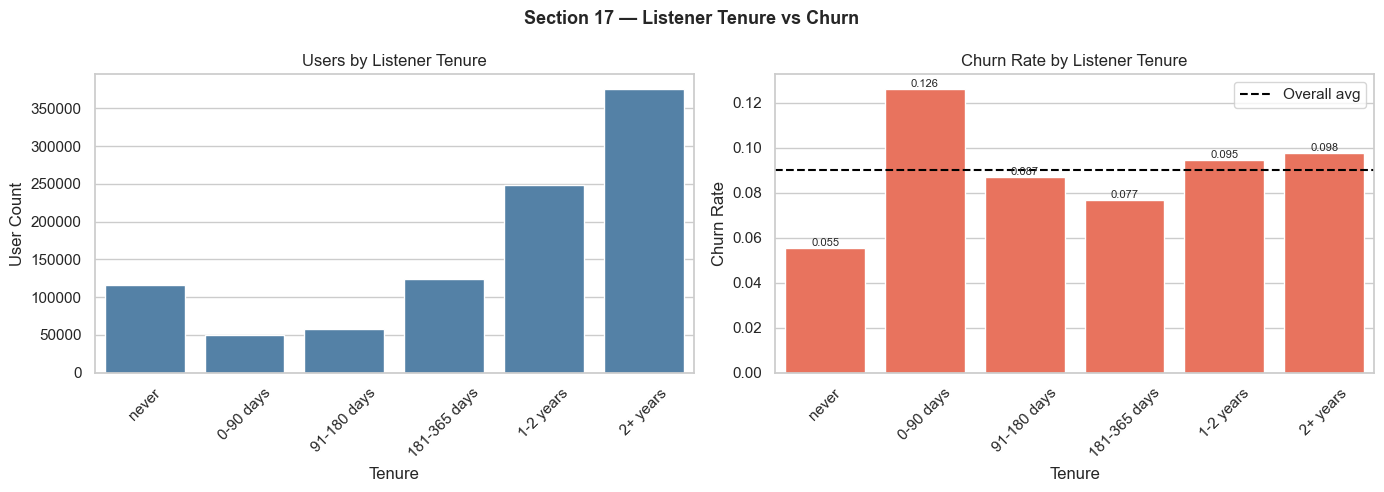

In [39]:
first_listen = con.execute("""
    SELECT
        msno,
        MIN(date) AS first_listen_date,
        MAX(date) AS last_listen_date,
        COUNT(DISTINCT date) AS active_days
    FROM logs
    GROUP BY msno
""").df()

first_labeled = first_listen.merge(labels_df, on='msno', how='right')

# Days since first listen = listener tenure
first_labeled['listener_tenure_days'] = first_labeled[
    'first_listen_date'].apply(
    lambda x: (pd.Timestamp('20170401') -
               pd.Timestamp(str(int(x)))).days
    if pd.notna(x) else 0
)

print(first_labeled['listener_tenure_days'].describe())

first_labeled['bucket'] = pd.cut(
    first_labeled['listener_tenure_days'],
    bins=[-1, 0, 90, 180, 365, 730, 9999],
    labels=['never', '0-90 days', '91-180 days',
            '181-365 days', '1-2 years', '2+ years']
)

summary = first_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Listener Tenure')
axes[0].set_xlabel('Tenure')
axes[0].set_ylabel('User Count')
axes[0].tick_params(axis='x', rotation=45)

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Listener Tenure')
axes[1].set_xlabel('Tenure')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 17 — Listener Tenure vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

  bucket  total_users  churn_rate
0      0       115800    0.055268
1    1-3        85800    0.109149
2    4-6        81391    0.100355
3   7-12       144109    0.093748
4  13-18       149824    0.100164
5  19-26       144526    0.105642


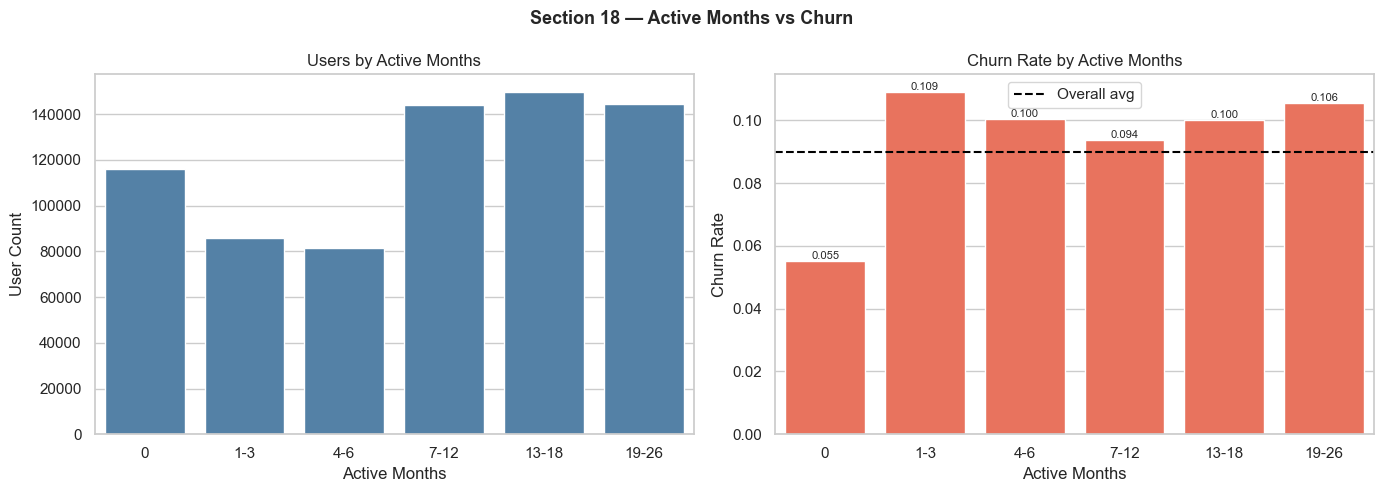

In [40]:
active_months = con.execute("""
    SELECT
        msno,
        COUNT(DISTINCT SUBSTR(CAST(date AS VARCHAR), 1, 6))
            AS active_months
    FROM logs
    GROUP BY msno
""").df()

months_labeled = active_months.merge(labels_df, on='msno', how='right')
months_labeled['active_months'] = months_labeled[
    'active_months'].fillna(0)

months_labeled['bucket'] = pd.cut(
    months_labeled['active_months'],
    bins=[-1, 0, 3, 6, 12, 18, 26],
    labels=['0', '1-3', '4-6', '7-12', '13-18', '19-26']
)

summary = months_labeled.groupby('bucket', observed=True).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

print(summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=summary, x='bucket', y='total_users',
            color='steelblue', ax=axes[0])
axes[0].set_title('Users by Active Months')
axes[0].set_xlabel('Active Months')
axes[0].set_ylabel('User Count')

sns.barplot(data=summary, x='bucket', y='churn_rate',
            color='tomato', ax=axes[1])
axes[1].set_title('Churn Rate by Active Months')
axes[1].set_xlabel('Active Months')
axes[1].set_ylabel('Churn Rate')
axes[1].axhline(y=0.0899, color='black',
                linestyle='--', label='Overall avg')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.3f}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 18 — Active Months vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


=== Last 30 Days ===
      bucket  total_users  churn_rate
0          0       216409    0.090985
1   very low       538650    0.092780
2        low       141544    0.082031
3     medium        42648    0.085162
4       high        16557    0.077852
5  very high        15152    0.074710

=== Last 15 Days ===
      bucket  total_users  churn_rate
0          0       255545    0.130470
1   very low       506340    0.074782
2        low       136245    0.076333
3     medium        41843    0.081280
4       high        16367    0.077167
5  very high        14620    0.072503


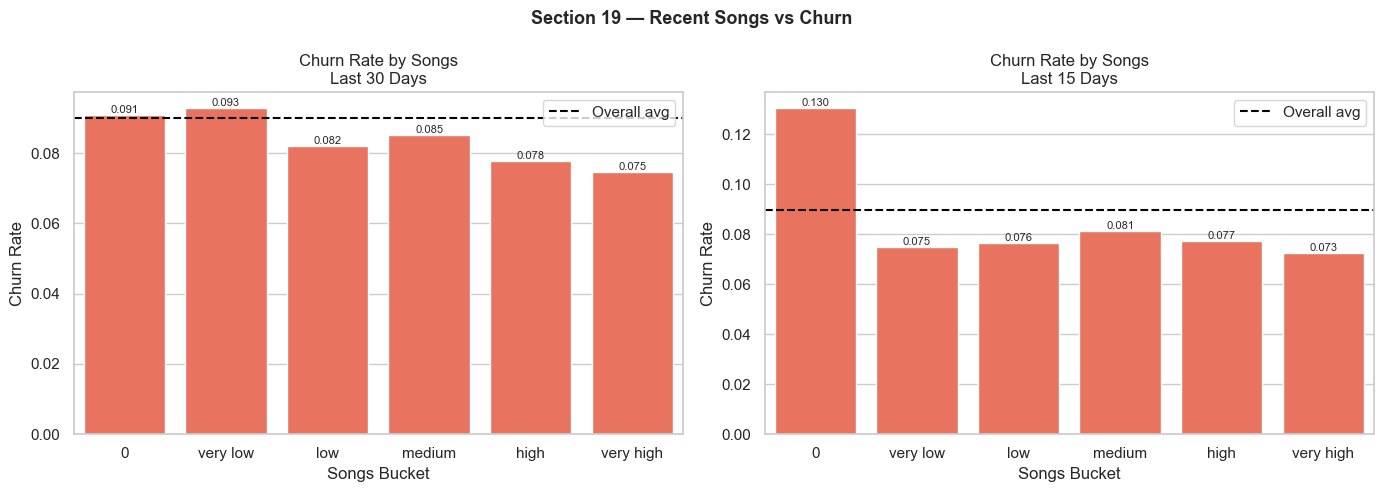

In [41]:
recent_songs = con.execute("""
    SELECT
        msno,
        SUM(CASE WHEN date >= 20170301
            THEN num_25+num_50+num_75+num_985+num_100
            ELSE 0 END) AS songs_30d,
        SUM(CASE WHEN date >= 20170316
            THEN num_25+num_50+num_75+num_985+num_100
            ELSE 0 END) AS songs_15d
    FROM logs
    GROUP BY msno
""").df()

songs_labeled = recent_songs.merge(labels_df, on='msno', how='right')
songs_labeled['songs_30d'] = songs_labeled['songs_30d'].fillna(0)
songs_labeled['songs_15d'] = songs_labeled['songs_15d'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, (col, label) in enumerate([
    ('songs_30d', 'Last 30 Days'),
    ('songs_15d', 'Last 15 Days')
]):
    q99 = songs_labeled[col][songs_labeled[col] > 0].quantile(0.99)
    songs_labeled['bucket'] = pd.cut(
        songs_labeled[col].clip(0, q99),
        bins=[-0.001, 0, q99*0.2, q99*0.4,
              q99*0.6, q99*0.8, q99],
        labels=['0', 'very low', 'low',
                'medium', 'high', 'very high']
    )

    summary = songs_labeled.groupby('bucket', observed=True).agg(
        total_users=('msno', 'count'),
        churn_rate=('is_churn', 'mean')
    ).reset_index()

    print(f"\n=== {label} ===")
    print(summary)

    sns.barplot(data=summary, x='bucket', y='churn_rate',
                color='tomato', ax=axes[idx])
    axes[idx].set_title(f'Churn Rate by Songs\n{label}')
    axes[idx].set_xlabel('Songs Bucket')
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].axhline(y=0.0899, color='black',
                      linestyle='--', label='Overall avg')
    axes[idx].legend()
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.3f}',
                          (p.get_x() + p.get_width()/2., p.get_height()),
                          ha='center', va='bottom', fontsize=8)

plt.suptitle('Section 19 — Recent Songs vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

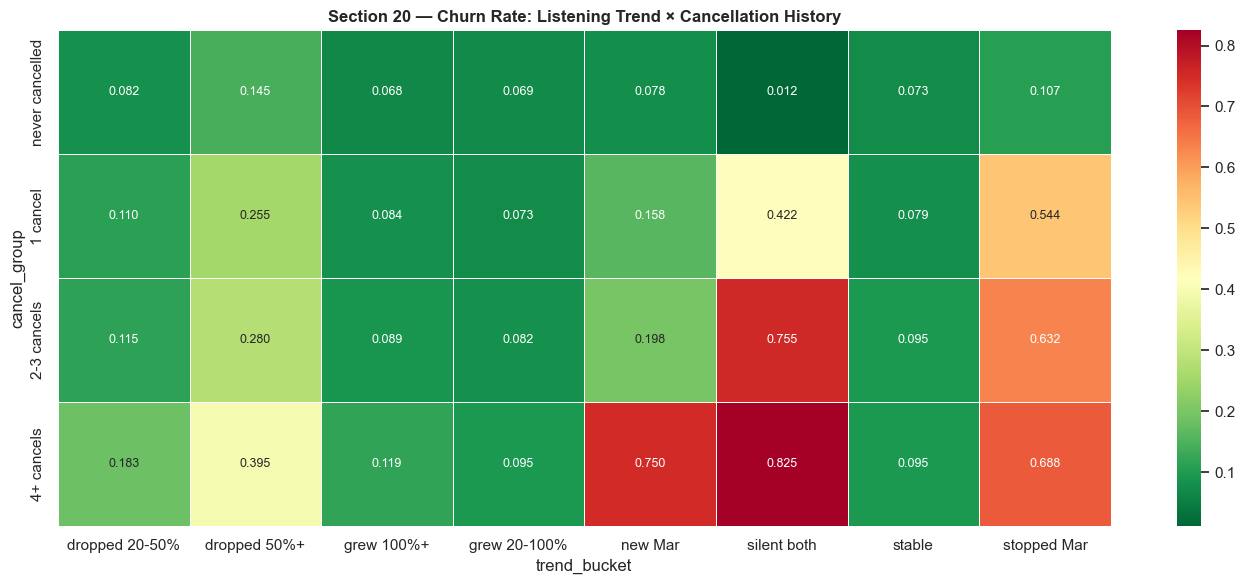

    trend_bucket cancel_group  total_users  churn_rate
23   silent both   4+ cancels           97    0.824742
22   silent both  2-3 cancels         3542    0.754941
19       new Mar   4+ cancels            8    0.750000
31   stopped Mar   4+ cancels           48    0.687500
30   stopped Mar  2-3 cancels         1151    0.632493
29   stopped Mar     1 cancel         5922    0.543735
21   silent both     1 cancel        21190    0.421897
7   dropped 50%+   4+ cancels          261    0.394636
6   dropped 50%+  2-3 cancels         4949    0.279652
5   dropped 50%+     1 cancel        20854    0.254723


In [43]:
# Get cancellation history from transactions
cancel_history = con.execute(f"""
    SELECT
        msno,
        SUM(is_cancel) AS total_cancellations,
        MAX(CASE WHEN is_cancel = 1
            THEN transaction_date ELSE NULL END) AS last_cancel_date
    FROM (
        SELECT * FROM '{PARQUET_DIR}transactions.parquet'
        UNION ALL
        SELECT * FROM '{PARQUET_DIR}transactions_v2.parquet'
    )
    WHERE payment_plan_days > 1
    GROUP BY msno
""").df()

# Merge trend + cancel + labels
cross2 = trend_labeled[['msno', 'trend_bucket']].merge(
    cancel_history, on='msno', how='left'
).merge(labels_df, on='msno', how='right')

cross2['total_cancellations'] = cross2['total_cancellations'].fillna(0)
cross2['trend_bucket'] = cross2['trend_bucket'].fillna('silent both')
cross2['cancel_group'] = pd.cut(
    cross2['total_cancellations'],
    bins=[-1, 0, 1, 3, 99999],
    labels=['never cancelled', '1 cancel',
            '2-3 cancels', '4+ cancels']
)

summary = cross2.groupby(
    ['trend_bucket', 'cancel_group'],
    observed=True
).agg(
    total_users=('msno', 'count'),
    churn_rate=('is_churn', 'mean')
).reset_index()

# Pivot for heatmap
pivot = summary.pivot(
    index='cancel_group',
    columns='trend_bucket',
    values='churn_rate'
)

plt.figure(figsize=(14, 6))
sns.heatmap(pivot, annot=True, fmt='.3f',
            cmap='RdYlGn_r', linewidths=0.5,
            annot_kws={'size': 9})
plt.title('Section 20 — Churn Rate: Listening Trend × Cancellation History',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print(summary.sort_values('churn_rate', ascending=False).head(10))

=== CORRELATION WITH CHURN ===
ratio_25: correlation = -0.0118
ratio_50: correlation = 0.0018
ratio_75: correlation = 0.0016
ratio_985: correlation = 0.0024
ratio_100: correlation = 0.0079


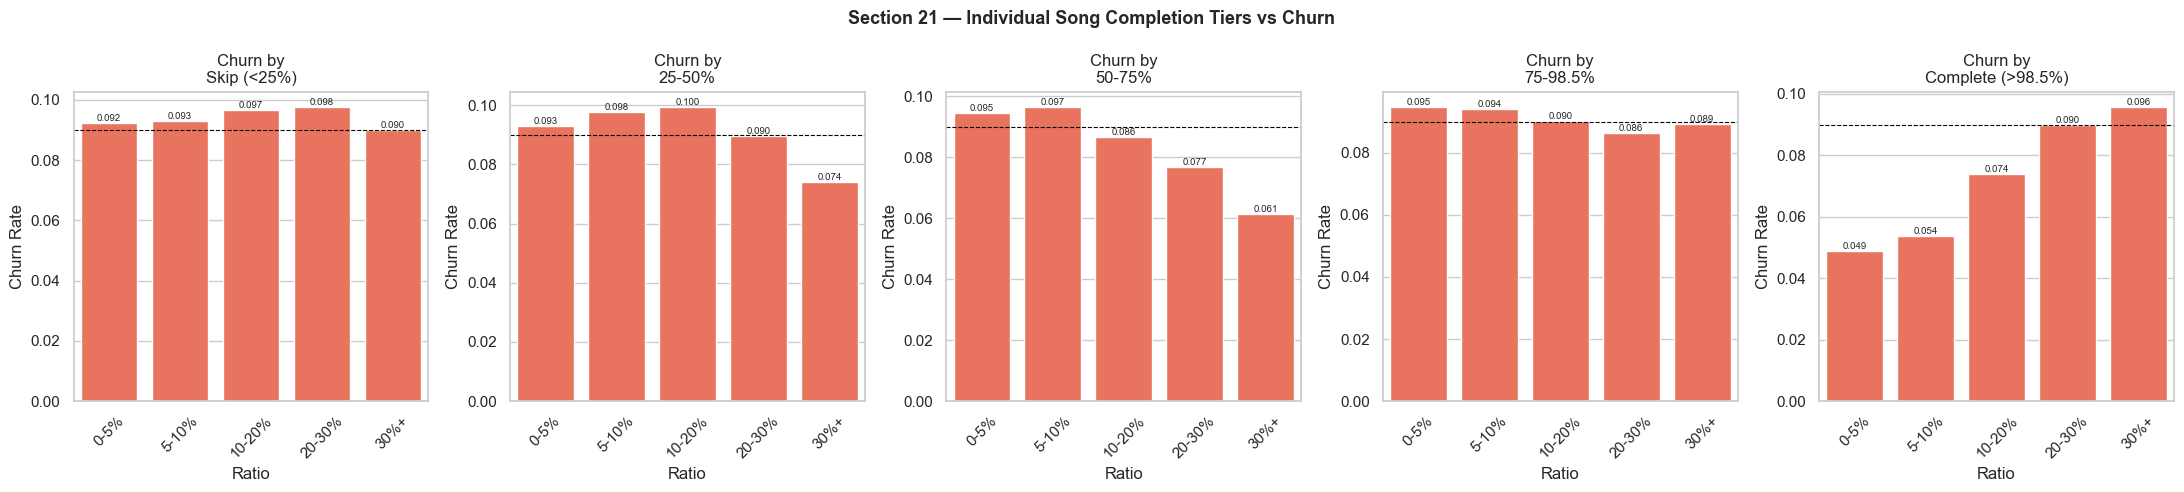

In [44]:
# Cell 23 — Individual completion tiers vs churn
tier_stats = con.execute("""
    SELECT
        msno,
        SUM(num_25)     AS total_num_25,
        SUM(num_50)     AS total_num_50,
        SUM(num_75)     AS total_num_75,
        SUM(num_985)    AS total_num_985,
        SUM(num_100)    AS total_num_100,
        SUM(num_25+num_50+num_75+num_985+num_100) AS total_songs,
        -- Ratios
        ROUND(SUM(num_25)*1.0/NULLIF(
            SUM(num_25+num_50+num_75+num_985+num_100),0),4) AS ratio_25,
        ROUND(SUM(num_50)*1.0/NULLIF(
            SUM(num_25+num_50+num_75+num_985+num_100),0),4) AS ratio_50,
        ROUND(SUM(num_75)*1.0/NULLIF(
            SUM(num_25+num_50+num_75+num_985+num_100),0),4) AS ratio_75,
        ROUND(SUM(num_985)*1.0/NULLIF(
            SUM(num_25+num_50+num_75+num_985+num_100),0),4) AS ratio_985,
        ROUND(SUM(num_100)*1.0/NULLIF(
            SUM(num_25+num_50+num_75+num_985+num_100),0),4) AS ratio_100
    FROM logs
    GROUP BY msno
""").df()

tiers_labeled = tier_stats.merge(labels_df, on='msno', how='right')

for col in ['ratio_25', 'ratio_50', 'ratio_75', 'ratio_985', 'ratio_100']:
    tiers_labeled[col] = tiers_labeled[col].fillna(-1)

print("=== CORRELATION WITH CHURN ===")
for col in ['ratio_25', 'ratio_50', 'ratio_75', 'ratio_985', 'ratio_100']:
    valid = tiers_labeled[tiers_labeled[col] >= 0]
    corr = valid[col].corr(valid['is_churn'])
    print(f"{col}: correlation = {corr:.4f}")

fig, axes = plt.subplots(1, 5, figsize=(22, 5))

for idx, (col, label) in enumerate([
    ('ratio_25', 'Skip (<25%)'),
    ('ratio_50', '25-50%'),
    ('ratio_75', '50-75%'),
    ('ratio_985', '75-98.5%'),
    ('ratio_100', 'Complete (>98.5%)')
]):
    temp = tiers_labeled[tiers_labeled[col] >= 0].copy()
    temp['bucket'] = pd.cut(
        temp[col],
        bins=[-0.001, 0.05, 0.1, 0.2, 0.3, 1.001],
        labels=['0-5%', '5-10%', '10-20%', '20-30%', '30%+']
    )
    summary = temp.groupby('bucket', observed=True).agg(
        churn_rate=('is_churn', 'mean'),
        count=('msno', 'count')
    ).reset_index()

    sns.barplot(data=summary, x='bucket', y='churn_rate',
                color='tomato', ax=axes[idx])
    axes[idx].set_title(f'Churn by\n{label}')
    axes[idx].set_xlabel('Ratio')
    axes[idx].set_ylabel('Churn Rate')
    axes[idx].axhline(y=0.0899, color='black',
                      linestyle='--', linewidth=0.8)
    axes[idx].tick_params(axis='x', rotation=45)
    for p in axes[idx].patches:
        axes[idx].annotate(f'{p.get_height():.3f}',
                          (p.get_x() + p.get_width()/2., p.get_height()),
                          ha='center', va='bottom', fontsize=7)

plt.suptitle('Section 21 — Individual Song Completion Tiers vs Churn',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [45]:
recent_completion = con.execute("""
    SELECT
        msno,
        ROUND(SUM(CASE WHEN date >= 20170301
            THEN num_100 ELSE 0 END)*1.0 /
            NULLIF(SUM(CASE WHEN date >= 20170301
            THEN num_25+num_50+num_75+num_985+num_100
            ELSE NULL END), 0), 4) AS completion_rate_30d,
        ROUND(SUM(CASE WHEN date >= 20170316
            THEN num_100 ELSE 0 END)*1.0 /
            NULLIF(SUM(CASE WHEN date >= 20170316
            THEN num_25+num_50+num_75+num_985+num_100
            ELSE NULL END), 0), 4) AS completion_rate_15d
    FROM logs
    GROUP BY msno
""").df()

rc_labeled = recent_completion.merge(labels_df, on='msno', how='right')

for col in ['completion_rate_30d', 'completion_rate_15d']:
    rc_labeled[col] = rc_labeled[col].fillna(-1)
    rc_labeled['bucket'] = pd.cut(
        rc_labeled[col],
        bins=[-2, -0.5, 0.2, 0.4, 0.6, 0.8, 1.001],
        labels=['no listening', '0-20%', '20-40%',
                '40-60%', '60-80%', '80-100%']
    )
    summary = rc_labeled.groupby('bucket', observed=True).agg(
        total_users=('msno', 'count'),
        churn_rate=('is_churn', 'mean')
    ).reset_index()
    print(f"\n=== {col} ===")
    print(summary)


=== completion_rate_30d ===
         bucket  total_users  churn_rate
0  no listening       216409    0.090985
1         0-20%        20921    0.096793
2        20-40%        46159    0.092918
3        40-60%       130910    0.092453
4        60-80%       267869    0.089574
5       80-100%       288692    0.087391

=== completion_rate_15d ===
         bucket  total_users  churn_rate
0  no listening       255545    0.130470
1         0-20%        22331    0.094667
2        20-40%        47029    0.074784
3        40-60%       123947    0.077977
4        60-80%       240998    0.075677
5       80-100%       281110    0.072765
